# 12 — Error Analysis et adjudication

Ce notebook explique **pourquoi** l'évaluation du notebook 11 reste provisoire. Il n'appelle aucun modèle et ne régénère aucune réponse : il relit uniquement les artefacts déjà produits.

Il poursuit quatre objectifs :

1. analyser les désaccords entre l'humain et GPT-5.6 sur la faithfulness, la correctness et le gagnant A/B ;
2. construire une taxonomie des échecs des variantes `compact_5k` et `extended_8k` ;
3. produire un dossier aveugle d'adjudication pour les seuls désaccords de faithfulness ;
4. établir les corrections expérimentales prioritaires sans diminuer artificiellement les seuils.

Le split `test` reste verrouillé et aucun résultat de test n'est chargé.

## 1. Dépendances et chemins

Seuls `pandas`, `numpy` et `matplotlib` sont nécessaires. L'exécution est locale, déterministe et sans coût API.

In [15]:
%pip install -q numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
from __future__ import annotations

import hashlib
import json
import os
import tempfile
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable, Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 220)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATASET_ROOT = PROJECT_ROOT / "data" / "processed" / "multidoc2dial_v1"
REPORTS_ROOT = PROJECT_ROOT / "reports" / "generated" / "multidoc2dial_v1"
CONFIG_PATH = PROJECT_ROOT / "configs" / "error_analysis_adjudication.json"

print(f"Project root : {PROJECT_ROOT}")
print(f"Configuration : {CONFIG_PATH}")

Project root : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant
Configuration : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\configs\error_analysis_adjudication.json


In [17]:
def load_json(path: Path) -> dict[str, Any]:
    value = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(value, dict):
        raise TypeError(f"La racine de {path} doit être un objet JSON")
    return value


def iter_jsonl(path: Path) -> Iterator[dict[str, Any]]:
    with path.open(encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, 1):
            if not line.strip():
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError as error:
                raise ValueError(f"JSONL invalide : {path}, ligne {line_number}") from error


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while block := handle.read(1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def stable_hash(value: Any) -> str:
    payload = json.dumps(value, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def write_json_atomic(path: Path, value: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile("w", encoding="utf-8", delete=False, dir=path.parent, suffix=".tmp") as handle:
        json.dump(value, handle, ensure_ascii=False, indent=2)
        handle.write("\n")
        temporary = Path(handle.name)
    os.replace(temporary, path)


def write_jsonl_atomic(path: Path, records: Iterable[dict[str, Any]]) -> int:
    path.parent.mkdir(parents=True, exist_ok=True)
    count = 0
    with tempfile.NamedTemporaryFile("w", encoding="utf-8", delete=False, dir=path.parent, suffix=".tmp") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")) + "\n")
            count += 1
        temporary = Path(handle.name)
    os.replace(temporary, path)
    return count


def artifact_metadata(path: Path, records: int | None = None) -> dict[str, Any]:
    result = {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "bytes": path.stat().st_size,
        "sha256": file_sha256(path),
    }
    if records is not None:
        result["records"] = records
    return result


def read_human_csv(path: Path) -> pd.DataFrame:
    header = path.read_text(encoding="utf-8-sig").splitlines()[0]
    separator = ";" if header.count(";") > header.count(",") else ","
    return pd.read_csv(path, dtype=str, keep_default_na=False, encoding="utf-8-sig", sep=separator)


def save_figure(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

## 2. Chargement et contrat des données

Le notebook relit exactement l'expérience du notebook 11. Les 400 candidats correspondent à `200 questions × 2 variantes`. Les annotations humaines portent sur 40 questions aveugles, donc 80 réponses individuelles.

In [18]:
config = load_json(CONFIG_PATH)
quality_experiment_id = config["source_quality_experiment_id"]
generation_experiment_id = config["source_generation_experiment_id"]

QUALITY_DATA_ROOT = DATASET_ROOT / "quality_evaluation_experiments" / quality_experiment_id
QUALITY_REPORT_ROOT = REPORTS_ROOT / "quality_evaluation_experiments" / quality_experiment_id
GENERATION_ROOT = DATASET_ROOT / "generation_experiments" / generation_experiment_id

quality_report_path = QUALITY_REPORT_ROOT / "answer_quality_report.json"
candidate_path = QUALITY_DATA_ROOT / "evaluation" / "candidate_metrics.jsonl"
pairwise_path = QUALITY_DATA_ROOT / "evaluation" / "pairwise_metrics.jsonl"
position_path = QUALITY_DATA_ROOT / "evaluation" / "position_bias_audit.jsonl"
human_path = QUALITY_REPORT_ROOT / "human_calibration_blind.csv"
generation_paths = {
    variant: GENERATION_ROOT / "generations" / f"validation_{variant}.jsonl"
    for variant in config["context_variants"]
}

required_paths = [quality_report_path, candidate_path, pairwise_path, position_path, human_path, *generation_paths.values()]
missing_paths = [str(path) for path in required_paths if not path.exists()]
assert not missing_paths, f"Artefacts manquants : {missing_paths}"

quality_report = load_json(quality_report_path)
candidate_df = pd.DataFrame(iter_jsonl(candidate_path))
pairwise_df = pd.DataFrame(iter_jsonl(pairwise_path))
position_df = pd.DataFrame(iter_jsonl(position_path))
human_df = read_human_csv(human_path)
generation_df = pd.concat(
    [pd.DataFrame(iter_jsonl(path)) for path in generation_paths.values()],
    ignore_index=True,
)

assert len(candidate_df) == config["quality_targets"]["expected_candidate_records"]
assert len(pairwise_df) == config["quality_targets"]["expected_pairwise_records"]
assert len(position_df) == config["quality_targets"]["expected_position_audit_records"]
assert len(human_df) == config["human_calibration"]["expected_examples"]
assert set(candidate_df["context_variant"]) == set(config["context_variants"])
assert set(candidate_df["domain"]) == {"dmv", "ssa", "va", "studentaid"}
assert set(candidate_df["example_id"]) == set(generation_df["example_id"])
assert set(candidate_df["context_variant"]) == set(generation_df["context_variant"])

input_hashes = {
    str(path.relative_to(PROJECT_ROOT)): file_sha256(path)
    for path in required_paths
}
experiment_fingerprint = stable_hash({"config": config, "inputs": input_hashes})
experiment_id = f"{config['experiment_name']}_{experiment_fingerprint[:10]}"
OUTPUT_ROOT = DATASET_ROOT / "error_analysis_experiments" / experiment_id
REPORT_ROOT = REPORTS_ROOT / "error_analysis_experiments" / experiment_id
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Expérience : {experiment_id}")
print(f"Candidats : {len(candidate_df)}; pairwise : {len(pairwise_df)}; humains : {len(human_df)}")
print("Appels OpenAI : 0; split test chargé : 0")

Expérience : answer_error_analysis_v1_f0e5c63a0a
Candidats : 400; pairwise : 200; humains : 40
Appels OpenAI : 0; split test chargé : 0


## 3. Reconstruction des 80 décisions humaines

Chaque ligne humaine contient A et B. Nous la transformons en 80 lignes, puis nous la joignons aux métriques du juge grâce au couple stable `(example_id, blind_label)`. La correctness du juge est reconvertie de `[0,1]` vers le barème humain `[0,4]`.

In [19]:
human_long_rows = []
for row in human_df.to_dict(orient="records"):
    for label in ("A", "B"):
        lower = label.lower()
        human_long_rows.append({
            "example_id": row["example_id"],
            "domain": row["domain"],
            "blind_label": label,
            "question": row["current_question"],
            "conversation_history": row["conversation_history"],
            "reference_answer": row["reference_answer"],
            "gold_evidence": row["gold_evidence"],
            "candidate_status": row[f"candidate_{lower}_status"],
            "candidate_answer": row[f"candidate_{lower}_answer"],
            "candidate_cited_sources": row[f"candidate_{lower}_cited_sources"],
            "human_faithfulness": row[f"human_{lower}_faithfulness"].strip().lower(),
            "human_correctness_0_to_4": row[f"human_{lower}_correctness_0_to_4"].strip(),
            "human_winner": row["human_winner"].strip(),
        })

human_long_df = pd.DataFrame(human_long_rows)
valid_faithfulness = set(config["adjudication"]["required_label_values"])
invalid_human = (
    ~human_long_df["human_faithfulness"].isin(valid_faithfulness)
    | ~human_long_df["human_correctness_0_to_4"].isin(["0", "1", "2", "3", "4"])
)
assert int(invalid_human.sum()) == config["quality_targets"]["maximum_invalid_human_labels"]
assert len(human_long_df) == config["human_calibration"]["expected_candidate_labels"]

metric_columns = [
    "example_id", "blind_label", "context_variant", "response_type", "context_answerability",
    "material_factual_claims", "faithfulness_pass", "citation_correctness_pass",
    "citation_completeness_pass", "faithfulness_score", "citation_correctness_score",
    "citation_completeness_score", "correctness_score", "relevance_score", "hallucination",
    "critical_error", "overall_pass", "abstention_quality", "contract_valid", "judge_rationale", "claims",
]
calibration_df = human_long_df.merge(
    candidate_df[metric_columns], on=["example_id", "blind_label"], how="left", validate="one_to_one"
)
assert calibration_df["context_variant"].notna().all()

calibration_df["judge_faithfulness"] = np.where(calibration_df["faithfulness_pass"], "pass", "fail")
calibration_df["faithfulness_agrees"] = calibration_df["human_faithfulness"] == calibration_df["judge_faithfulness"]
calibration_df["human_correctness_0_to_4"] = calibration_df["human_correctness_0_to_4"].astype(float)
calibration_df["judge_correctness_0_to_4"] = calibration_df["correctness_score"].astype(float) * 4.0
calibration_df["correctness_signed_difference"] = (
    calibration_df["judge_correctness_0_to_4"] - calibration_df["human_correctness_0_to_4"]
)
calibration_df["correctness_absolute_difference"] = calibration_df["correctness_signed_difference"].abs()

print(f"Décisions faithfulness : {len(calibration_df)}")
print(f"Accords : {int(calibration_df['faithfulness_agrees'].sum())}; désaccords : {int((~calibration_df['faithfulness_agrees']).sum())}")

Décisions faithfulness : 80
Accords : 58; désaccords : 22


## 4. Où le juge et l'humain divergent-ils sur la faithfulness ?

La matrice de confusion distingue deux situations différentes :

- `humain=fail / juge=pass` : le juge est potentiellement trop permissif ;
- `humain=pass / juge=fail` : le juge est potentiellement trop strict.

Ce tableau ne décide pas qui a raison. C'est précisément le rôle de l'adjudication aveugle.

juge,fail,pass
humain,,
fail,2,14
pass,8,56


,disagreement_direction,domain,context_variant,cases,mean_material_claims,citation_correctness_pass_rate,citation_completeness_pass_rate,hallucination_rate
5,human_fail__judge_pass,studentaid,extended_8k,3,1.3333,0.6667,0.6667,0.0
8,human_pass__judge_fail,dmv,compact_5k,3,3.6667,0.0000,1.0000,0.0
9,human_pass__judge_fail,dmv,extended_8k,3,3.6667,0.0000,1.0000,0.0
0,human_fail__judge_pass,dmv,compact_5k,2,0.5000,1.0000,1.0000,0.0
2,human_fail__judge_pass,ssa,compact_5k,2,3.5000,0.0000,1.0000,0.0
4,human_fail__judge_pass,studentaid,compact_5k,2,2.0000,0.5000,0.5000,0.0
6,human_fail__judge_pass,va,compact_5k,2,2.0000,1.0000,0.0000,0.0
1,human_fail__judge_pass,dmv,extended_8k,1,1.0000,1.0000,1.0000,0.0
3,human_fail__judge_pass,ssa,extended_8k,1,4.0000,0.0000,0.0000,0.0
7,human_fail__judge_pass,va,extended_8k,1,3.0000,1.0000,0.0000,0.0


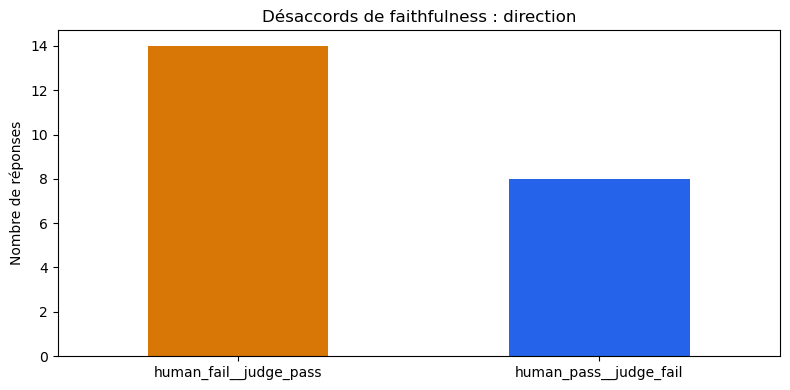

In [20]:
faith_confusion = pd.crosstab(
    calibration_df["human_faithfulness"],
    calibration_df["judge_faithfulness"],
    rownames=["humain"],
    colnames=["juge"],
    dropna=False,
)
display(faith_confusion)

faith_disagreements_df = calibration_df[~calibration_df["faithfulness_agrees"]].copy()
faith_disagreements_df["disagreement_direction"] = np.where(
    faith_disagreements_df["human_faithfulness"] == "fail",
    "human_fail__judge_pass",
    "human_pass__judge_fail",
)
faith_disagreements_df["claims_json"] = faith_disagreements_df["claims"].map(
    lambda value: json.dumps(value, ensure_ascii=False)
)

faith_breakdown = (
    faith_disagreements_df.groupby(["disagreement_direction", "domain", "context_variant"], dropna=False)
    .agg(
        cases=("example_id", "count"),
        mean_material_claims=("material_factual_claims", "mean"),
        citation_correctness_pass_rate=("citation_correctness_pass", "mean"),
        citation_completeness_pass_rate=("citation_completeness_pass", "mean"),
        hallucination_rate=("hallucination", "mean"),
    )
    .reset_index()
    .sort_values(["cases", "disagreement_direction"], ascending=[False, True])
)
display(faith_breakdown.round(4))

direction_counts = faith_disagreements_df["disagreement_direction"].value_counts()
ax = direction_counts.plot(kind="bar", color=["#d97706", "#2563eb"], figsize=(8, 4))
ax.set_title("Désaccords de faithfulness : direction")
ax.set_xlabel("")
ax.set_ylabel("Nombre de réponses")
ax.tick_params(axis="x", rotation=0)
faith_plot_path = REPORT_ROOT / "faithfulness_disagreement_directions.png"
save_figure(faith_plot_path)

## 5. Dossier d'adjudication aveugle

Le fichier d'adjudication masque volontairement :

- la variante réelle 5k/8k ;
- le label humain initial ;
- le label et le raisonnement de GPT-5.6.

L'adjudicateur voit uniquement la question, la réponse, les preuves gold et les sources réellement citées. Le fichier n'est créé qu'une fois et les futurs `Run All` ne remplacent jamais les annotations déjà saisies.

In [21]:
internal_disagreement_columns = [
    "example_id", "domain", "blind_label", "context_variant", "response_type", "question",
    "human_faithfulness", "judge_faithfulness", "disagreement_direction", "candidate_answer",
    "candidate_cited_sources", "citation_correctness_pass", "citation_completeness_pass",
    "hallucination", "judge_rationale", "claims_json",
]
internal_disagreement_records = faith_disagreements_df[internal_disagreement_columns].to_dict(orient="records")
disagreement_path = OUTPUT_ROOT / "faithfulness_disagreements.jsonl"
write_jsonl_atomic(disagreement_path, internal_disagreement_records)

blind_columns = [
    "example_id", "domain", "blind_label", "question", "conversation_history", "reference_answer",
    "gold_evidence", "candidate_status", "candidate_answer", "candidate_cited_sources",
    "adjudicated_faithfulness", "adjudication_notes",
]
blind_rows = []
for row in faith_disagreements_df.to_dict(orient="records"):
    blind_rows.append({
        "example_id": row["example_id"],
        "domain": row["domain"],
        "blind_label": row["blind_label"],
        "question": row["question"],
        "conversation_history": row["conversation_history"],
        "reference_answer": row["reference_answer"],
        "gold_evidence": row["gold_evidence"],
        "candidate_status": row["candidate_status"],
        "candidate_answer": row["candidate_answer"],
        "candidate_cited_sources": row["candidate_cited_sources"],
        "adjudicated_faithfulness": "",
        "adjudication_notes": "",
    })

expected_blind_df = pd.DataFrame(blind_rows, columns=blind_columns).sort_values(
    ["domain", "example_id", "blind_label"]
).reset_index(drop=True)
adjudication_path = REPORT_ROOT / config["adjudication"]["blind_filename"]
if not adjudication_path.exists():
    expected_blind_df.to_csv(adjudication_path, index=False, encoding="utf-8-sig", sep=";")
    print(f"Dossier aveugle créé : {adjudication_path}")
else:
    existing_adjudication_df = pd.read_csv(
        adjudication_path, dtype=str, keep_default_na=False, encoding="utf-8-sig", sep=";"
    )
    identity_columns = ["example_id", "blind_label"]
    assert existing_adjudication_df[identity_columns].equals(expected_blind_df[identity_columns]), (
        "Le dossier d'adjudication existant ne correspond plus aux désaccords courants"
    )
    assert set(blind_columns).issubset(existing_adjudication_df.columns)
    print(f"Dossier aveugle préservé : {adjudication_path}")

adjudication_df = pd.read_csv(
    adjudication_path, dtype=str, keep_default_na=False, encoding="utf-8-sig", sep=";"
)
valid_adjudication = adjudication_df["adjudicated_faithfulness"].isin(valid_faithfulness)
adjudication_completed = int(valid_adjudication.sum())
adjudication_total = len(adjudication_df)

judge_adjudicated_agreement = None
human_adjudicated_agreement = None
adjusted_judge_faithfulness_agreement = None
if adjudication_completed:
    completed = adjudication_df[valid_adjudication].merge(
        faith_disagreements_df[["example_id", "blind_label", "human_faithfulness", "judge_faithfulness"]],
        on=["example_id", "blind_label"], how="left", validate="one_to_one",
    )
    judge_adjudicated_agreement = float(
        (completed["adjudicated_faithfulness"] == completed["judge_faithfulness"]).mean()
    )
    human_adjudicated_agreement = float(
        (completed["adjudicated_faithfulness"] == completed["human_faithfulness"]).mean()
    )
    if adjudication_completed == adjudication_total:
        automatic_agreements = int(calibration_df["faithfulness_agrees"].sum())
        judge_wins = int((completed["adjudicated_faithfulness"] == completed["judge_faithfulness"]).sum())
        adjusted_judge_faithfulness_agreement = (automatic_agreements + judge_wins) / len(calibration_df)

print(f"Adjudication : {adjudication_completed}/{adjudication_total}")
if adjusted_judge_faithfulness_agreement is not None:
    print(f"Accord faithfulness du juge après adjudication : {adjusted_judge_faithfulness_agreement:.2%}")

Dossier aveugle préservé : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\reports\generated\multidoc2dial_v1\error_analysis_experiments\answer_error_analysis_v1_f0e5c63a0a\faithfulness_adjudication_blind.csv
Adjudication : 22/22
Accord faithfulness du juge après adjudication : 78.75%


## 6. Désaccords de correctness

La MAE moyenne peut cacher quelques divergences importantes. Nous séparons donc :

- les cas où le juge est plus sévère que l'humain ;
- les cas où le juge est plus généreux ;
- les écarts absolus d'au moins 2 points sur 4.

In [22]:
correctness_by_group = (
    calibration_df.groupby(["domain", "context_variant"])
    .agg(
        cases=("example_id", "count"),
        human_mean=("human_correctness_0_to_4", "mean"),
        judge_mean=("judge_correctness_0_to_4", "mean"),
        mae=("correctness_absolute_difference", "mean"),
        judge_minus_human=("correctness_signed_difference", "mean"),
        within_one=("correctness_absolute_difference", lambda values: float((values <= 1.0).mean())),
    )
    .reset_index()
)
display(correctness_by_group.round(4))

large_correctness_df = calibration_df[
    calibration_df["correctness_absolute_difference"] >= config["analysis"]["large_correctness_difference"]
].copy()
large_correctness_df["difference_direction"] = np.select(
    [
        large_correctness_df["correctness_signed_difference"] > 0,
        large_correctness_df["correctness_signed_difference"] < 0,
    ],
    ["judge_more_generous", "judge_more_severe"],
    default="equal",
)
display(
    large_correctness_df[[
        "example_id", "domain", "blind_label", "context_variant", "human_correctness_0_to_4",
        "judge_correctness_0_to_4", "correctness_signed_difference", "correctness_absolute_difference",
        "judge_rationale",
    ]].sort_values("correctness_absolute_difference", ascending=False)
)
large_correctness_path = OUTPUT_ROOT / "large_correctness_disagreements.jsonl"
large_correctness_records = large_correctness_df[
    [
        "example_id", "domain", "blind_label", "context_variant", "question", "candidate_answer",
        "human_correctness_0_to_4", "judge_correctness_0_to_4", "correctness_signed_difference",
        "difference_direction", "judge_rationale",
    ]
].to_dict(orient="records")
write_jsonl_atomic(large_correctness_path, large_correctness_records)

,domain,context_variant,cases,human_mean,judge_mean,mae,judge_minus_human,within_one
0,dmv,compact_5k,10,2.5,2.6,0.5,0.1,0.9
1,dmv,extended_8k,10,3.0,2.8,0.6,-0.2,0.9
2,ssa,compact_5k,10,3.9,3.9,0.0,0.0,1.0
3,ssa,extended_8k,10,3.8,3.8,0.2,0.0,1.0
4,studentaid,compact_5k,10,3.1,3.4,0.7,0.3,0.8
5,studentaid,extended_8k,10,2.8,3.4,0.6,0.6,0.8
6,va,compact_5k,10,3.0,3.4,0.4,0.4,0.9
7,va,extended_8k,10,3.1,3.5,0.4,0.4,0.9


,example_id,domain,blind_label,context_variant,human_correctness_0_to_4,judge_correctness_0_to_4,correctness_signed_difference,correctness_absolute_difference,judge_rationale
5,eval_5fd8ac9b733e3ebdac23e85b,dmv,B,compact_5k,0.0,3.0,3.0,3.0,"The abstention is justified by the missing checklist, but the source inventory is unnecessary and the intended process is already reasonably clear."
47,eval_b85ec3898998da8214e3a902,studentaid,B,extended_8k,1.0,4.0,3.0,3.0,"The context is insufficient, and the response appropriately requests clarification while suggesting plausible meanings. Its material source-coverage claims nevertheless lack inline citations."
54,eval_44dfc2e91a22837ea94f6070,studentaid,A,compact_5k,0.0,3.0,3.0,3.0,"Abstention is appropriate because the retrieved context lacks student-loan forbearance information. However, saying the sources only cover VA decision reviews is inaccurate; they also cover DMV and military-record re..."
4,eval_5fd8ac9b733e3ebdac23e85b,dmv,A,extended_8k,1.0,3.0,2.0,2.0,"The retrieved context lacks the registration-transfer checklist, so abstention is appropriate, though the conversation already indicates the likely process."
46,eval_b85ec3898998da8214e3a902,studentaid,A,compact_5k,1.0,3.0,2.0,2.0,"The retrieved sources do not address loan security or identity theft, so abstaining is appropriate. However, the source-coverage claims lack inline citations, and the reply could ask a clearer follow-up question."
55,eval_44dfc2e91a22837ea94f6070,studentaid,B,extended_8k,1.0,3.0,2.0,2.0,"The retrieved context cannot answer the student-loan question, so requesting clarification is appropriate. The VA suggestion is somewhat irrelevant but conditional and not misleading."
64,eval_3d64006e806a44fc83f60f49,va,A,compact_5k,1.0,3.0,2.0,2.0,"The retrieved sources are irrelevant to the VA requirement, so abstention is appropriate. However, factual source-characterization claims lack citations, and the answer does not leverage the conversation’s prior conf..."
65,eval_3d64006e806a44fc83f60f49,va,B,extended_8k,1.0,3.0,2.0,2.0,"The retrieved context cannot answer the VA question, making abstention appropriate. Its factual source descriptions are uncited, and it overlooks the confirmation already present in the conversation."


8

## 7. Désaccords sur le gagnant A/B

Le pairwise répond à une question globale : quelle réponse est préférable ? Il est analysé séparément de la faithfulness, car une réponse peut être parfaitement sourcée mais moins pertinente ou moins complète.

In [23]:
human_pairwise_df = human_df[["example_id", "domain", "human_winner"]].copy()
human_pairwise_df = human_pairwise_df.merge(
    pairwise_df[["example_id", "winner_label", "winner_variant", "margin", "confidence", "preferred_reasons", "rationale"]],
    on="example_id", how="left", validate="one_to_one",
)
human_pairwise_df["agrees"] = human_pairwise_df["human_winner"] == human_pairwise_df["winner_label"]
pairwise_confusion = pd.crosstab(
    human_pairwise_df["human_winner"], human_pairwise_df["winner_label"],
    rownames=["humain"], colnames=["juge"], dropna=False,
)
display(pairwise_confusion)

pairwise_disagreements_df = human_pairwise_df[~human_pairwise_df["agrees"]].copy()
display(pairwise_disagreements_df[[
    "example_id", "domain", "human_winner", "winner_label", "winner_variant", "margin", "confidence", "rationale"
]])

pairwise_disagreement_path = OUTPUT_ROOT / "pairwise_disagreements.jsonl"
write_jsonl_atomic(pairwise_disagreement_path, pairwise_disagreements_df.to_dict(orient="records"))
print(f"Accord pairwise : {human_pairwise_df['agrees'].mean():.2%}; désaccords : {len(pairwise_disagreements_df)}")

juge,A,B,tie
humain,,,
A,6,1,2
B,2,11,1
tie,3,2,12


,example_id,domain,human_winner,winner_label,winner_variant,margin,confidence,rationale
0,eval_319526abeb9f7b468dafaeb7,dmv,tie,A,extended_8k,small,high,"Both give correct insurance guidance, but A also addresses the personal-experience question and provides a supported submission option."
3,eval_3f8341a5f07f54f3e0aa4d73,dmv,B,A,compact_5k,small,medium,"Both miss the intended answer. A is safer and avoids B's categorical, potentially misleading title requirement, though its clarification is unnecessary."
5,eval_4c23f0a3b64a4c6f301da603,dmv,tie,A,compact_5k,small,medium,"Both answers are substantively correct, but A places citations with nearly every claim; B's end-only citation bundle has weaker attribution and completeness."
17,eval_d89d58225803a8a55e2aa307,ssa,tie,A,extended_8k,small,high,"Both answers are substantively correct, but A aligns each claim with an individually supporting citation."
19,eval_0faa08da220f7d21c50d55bd,ssa,A,tie,tie,none,high,"Both answers are fully grounded and correct; A adds a supported reinstatement detail, while B is slightly more concise."
23,eval_b85ec3898998da8214e3a902,studentaid,tie,B,extended_8k,small,high,"Both appropriately avoid an unsupported answer, but B is more useful because it explicitly asks the user to clarify what “loan security” means."
25,eval_97934d808cf44048a01ab449,studentaid,A,B,compact_5k,small,medium,Both are fully correct and supported; B conveys the same essential information more concisely with cleaner citation use.
30,eval_e04a0411b0ed504a9270fbf9,va,B,A,extended_8k,small,high,"Both answers are substantively correct, and B is more tailored to separation. A narrowly wins because every cited source supports its associated claims, while B incorrectly attributes two claims to S4."
33,eval_17ea490b27ffebf49f120340,va,B,tie,tie,none,high,"Both answers are accurate, relevant, concise, and fully cited; the minor wording difference is not meaningful."
37,eval_738621700866305314cf5197,va,A,tie,tie,none,high,"Both are faithful, correct, and similarly relevant; both share the same notable omission about the documented disease association."


Accord pairwise : 72.50%; désaccords : 11


## 8. Taxonomie des échecs de production

Les métriques sont multi-label : une même réponse peut échouer simultanément sur les citations, la correctness et la pertinence. Une catégorie principale est ensuite attribuée selon une priorité explicite afin de compter 400 réponses sans double comptage.

context_variant,compact_5k,extended_8k
failure,,
abstention,0.035,0.015
citation_completeness,0.070,0.070
citation_correctness,0.240,0.255
contract,0.030,0.015
correctness,0.180,0.165
critical_error,0.045,0.035
faithfulness,0.105,0.070
hallucination,0.015,0.010
relevance,0.100,0.090


context_variant,compact_5k,extended_8k
primary_failure,,
citation_completeness,9,5
citation_correctness,27,35
correctness,18,15
critical_error,9,7
faithfulness,14,10
hallucination,1,0
passed,122,128


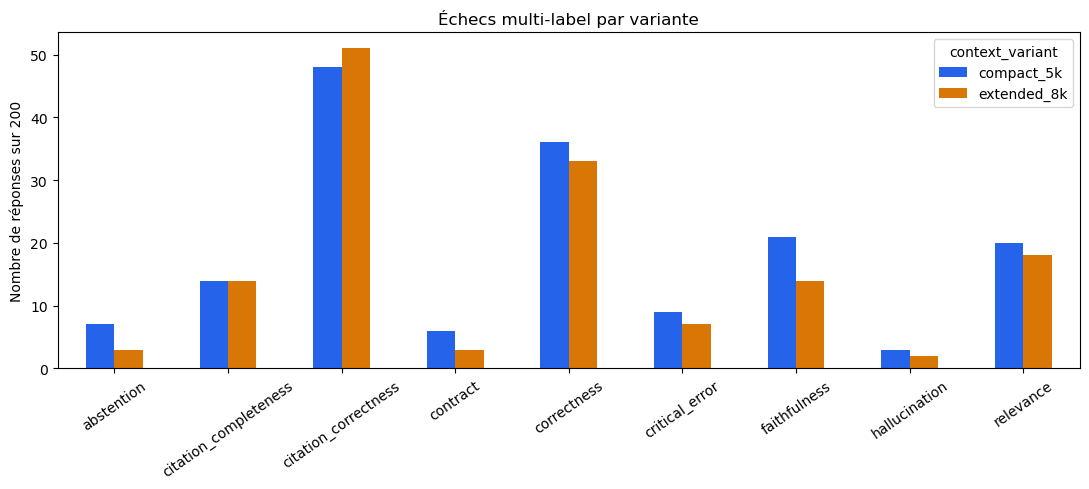

In [24]:
score_threshold = float(config["analysis"]["minimum_score_pass_0_to_1"])
failure_df = candidate_df.copy()
failure_df["fail_critical_error"] = failure_df["critical_error"].astype(bool)
failure_df["fail_hallucination"] = failure_df["hallucination"].astype(bool)
failure_df["fail_faithfulness"] = ~failure_df["faithfulness_pass"].astype(bool)
failure_df["fail_citation_correctness"] = ~failure_df["citation_correctness_pass"].astype(bool)
failure_df["fail_citation_completeness"] = ~failure_df["citation_completeness_pass"].astype(bool)
failure_df["fail_correctness"] = failure_df["correctness_score"].astype(float) < score_threshold
failure_df["fail_relevance"] = failure_df["relevance_score"].astype(float) < score_threshold
failure_df["fail_abstention"] = failure_df["abstention_quality"].isin(["incorrect", "missed"])
failure_df["fail_contract"] = ~failure_df["contract_valid"].astype(bool)

failure_flag_map = {
    "critical_error": "fail_critical_error",
    "hallucination": "fail_hallucination",
    "faithfulness": "fail_faithfulness",
    "citation_correctness": "fail_citation_correctness",
    "citation_completeness": "fail_citation_completeness",
    "correctness": "fail_correctness",
    "relevance": "fail_relevance",
    "abstention": "fail_abstention",
    "contract": "fail_contract",
}

def primary_failure(row: pd.Series) -> str:
    if bool(row["overall_pass"]):
        return "passed"
    for name in config["analysis"]["primary_failure_priority"]:
        flag = failure_flag_map.get(name)
        if flag and bool(row[flag]):
            return name
    return "other"


failure_df["primary_failure"] = failure_df.apply(primary_failure, axis=1)
flag_columns = list(failure_flag_map.values())
failure_df["failure_count"] = failure_df[flag_columns].sum(axis=1).astype(int)

multi_label_rows = []
for variant, group in failure_df.groupby("context_variant"):
    for failure_name, flag_column in failure_flag_map.items():
        multi_label_rows.append({
            "context_variant": variant,
            "failure": failure_name,
            "count": int(group[flag_column].sum()),
            "rate": float(group[flag_column].mean()),
        })
failure_multilabel_df = pd.DataFrame(multi_label_rows)
display(failure_multilabel_df.pivot(index="failure", columns="context_variant", values="rate").round(4))

primary_failure_df = (
    failure_df.groupby(["context_variant", "primary_failure"])
    .size().rename("count").reset_index()
)
display(primary_failure_df.pivot(index="primary_failure", columns="context_variant", values="count").fillna(0).astype(int))

failure_plot = failure_multilabel_df.pivot(index="failure", columns="context_variant", values="count").fillna(0)
ax = failure_plot.plot(kind="bar", figsize=(11, 5), color=["#2563eb", "#d97706"])
ax.set_title("Échecs multi-label par variante")
ax.set_xlabel("")
ax.set_ylabel("Nombre de réponses sur 200")
ax.tick_params(axis="x", rotation=35)
failure_plot_path = REPORT_ROOT / "failure_taxonomy_by_variant.png"
save_figure(failure_plot_path)

## 9. Comparaison appariée 5k contre 8k

Comparer seulement `61 %` à `64 %` masque les changements question par question. L'analyse appariée compte les questions où les deux réussissent, où une seule variante réussit et où les deux échouent.

,questions
outcome,
both_pass,104
extended_only,24
compact_only,18
both_fail,54


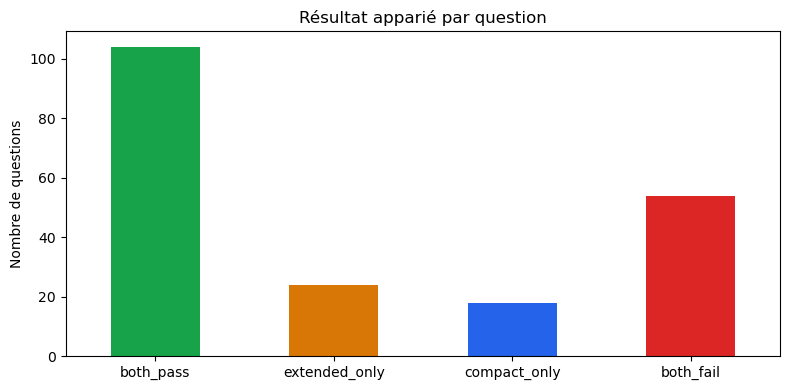

,domain,context_variant,responses,overall_pass_rate,faithfulness_fail_rate,citation_correctness_fail_rate,correctness_fail_rate,hallucination_rate
0,dmv,compact_5k,50,0.56,0.16,0.28,0.26,0.00
1,dmv,extended_8k,50,0.64,0.12,0.24,0.20,0.00
2,ssa,compact_5k,50,0.58,0.08,0.28,0.24,0.02
3,ssa,extended_8k,50,0.68,0.04,0.14,0.22,0.00
4,studentaid,compact_5k,50,0.58,0.10,0.20,0.16,0.02
5,studentaid,extended_8k,50,0.58,0.06,0.32,0.16,0.02
6,va,compact_5k,50,0.72,0.08,0.20,0.06,0.02
7,va,extended_8k,50,0.66,0.06,0.32,0.08,0.02


In [25]:
paired_pass = candidate_df.pivot(
    index="example_id", columns="context_variant", values="overall_pass"
).astype(bool)
paired_pass["outcome"] = np.select(
    [
        paired_pass["compact_5k"] & paired_pass["extended_8k"],
        ~paired_pass["compact_5k"] & paired_pass["extended_8k"],
        paired_pass["compact_5k"] & ~paired_pass["extended_8k"],
    ],
    ["both_pass", "extended_only", "compact_only"],
    default="both_fail",
)
paired_outcomes = paired_pass["outcome"].value_counts().reindex(
    ["both_pass", "extended_only", "compact_only", "both_fail"], fill_value=0
)
display(paired_outcomes.rename("questions").to_frame())

ax = paired_outcomes.plot(kind="bar", figsize=(8, 4), color=["#16a34a", "#d97706", "#2563eb", "#dc2626"])
ax.set_title("Résultat apparié par question")
ax.set_xlabel("")
ax.set_ylabel("Nombre de questions")
ax.tick_params(axis="x", rotation=0)
paired_plot_path = REPORT_ROOT / "paired_variant_outcomes.png"
save_figure(paired_plot_path)

domain_failure = (
    failure_df.groupby(["domain", "context_variant"])
    .agg(
        responses=("example_id", "count"),
        overall_pass_rate=("overall_pass", "mean"),
        faithfulness_fail_rate=("fail_faithfulness", "mean"),
        citation_correctness_fail_rate=("fail_citation_correctness", "mean"),
        correctness_fail_rate=("fail_correctness", "mean"),
        hallucination_rate=("hallucination", "mean"),
    )
    .reset_index()
)
display(domain_failure.round(4))

## 10. Casebook des échecs

Le casebook fournit des exemples inspectables par catégorie principale et variante. Il conserve la réponse, les claims extraits et le raisonnement du juge afin de transformer les métriques en corrections de prompt ou de validation concrètes.

In [26]:
generation_lookup = {
    (row["example_id"], row["context_variant"]): row
    for row in generation_df.to_dict(orient="records")
}
max_cases = int(config["analysis"]["maximum_examples_per_failure_bucket"])
casebook_records = []
for (variant, failure_name), group in failure_df[failure_df["primary_failure"] != "passed"].groupby(
    ["context_variant", "primary_failure"]
):
    ordered = group.sort_values(
        ["critical_error", "hallucination", "failure_count", "correctness_score", "citation_correctness_score"],
        ascending=[False, False, False, True, True],
    ).head(max_cases)
    for row in ordered.to_dict(orient="records"):
        generation = generation_lookup[(row["example_id"], row["context_variant"])]
        casebook_records.append({
            "example_id": row["example_id"],
            "domain": row["domain"],
            "context_variant": variant,
            "primary_failure": failure_name,
            "all_failure_flags": [name for name, flag in failure_flag_map.items() if bool(row[flag])],
            "answer": generation["answer"],
            "used_source_ids": generation["used_source_ids"],
            "judge_rationale": row["judge_rationale"],
            "claims": row["claims"],
            "metrics": {
                "faithfulness_score": row["faithfulness_score"],
                "citation_correctness_score": row["citation_correctness_score"],
                "citation_completeness_score": row["citation_completeness_score"],
                "correctness_score": row["correctness_score"],
                "relevance_score": row["relevance_score"],
                "overall_pass": row["overall_pass"],
            },
        })

casebook_path = OUTPUT_ROOT / "failure_casebook.jsonl"
write_jsonl_atomic(casebook_path, casebook_records)
print(f"Casebook : {len(casebook_records)} cas représentatifs")

Casebook : 51 cas représentatifs


## 11. Priorités d'ingénierie

Les recommandations ci-dessous sont dérivées des résultats. Elles ne changent aucun seuil et ne sélectionnent aucune variante non éligible.

In [27]:
failure_totals = (
    failure_multilabel_df.groupby("failure")["count"].sum().sort_values(ascending=False)
)
top_failure = str(failure_totals.index[0])
top_failure_count = int(failure_totals.iloc[0])
faithfulness_target = float(config["human_calibration"]["minimum_faithfulness_agreement"])

recommendations = []

if adjudication_completed < adjudication_total:
    recommendations.extend([
        {
            "action": "Adjudicate faithfulness disagreements",
            "reason": f"Il reste {adjudication_total - adjudication_completed} désaccords sans décision finale.",
            "success_criterion": f"{adjudication_total}/{adjudication_total} labels aveugles complétés.",
        },
        {
            "action": "Refine the judge rubric only after adjudication",
            "reason": "La direction des erreurs doit déterminer si le prompt juge est trop strict ou trop permissif.",
            "success_criterion": f"Accord faithfulness post-adjudication >= {faithfulness_target:.0%}.",
        },
    ])
elif (
    adjusted_judge_faithfulness_agreement is None
    or adjusted_judge_faithfulness_agreement < faithfulness_target
):
    recommendations.append({
        "action": "Refine and revalidate the faithfulness judge rubric",
        "reason": (
            f"L'accord post-adjudication du juge est de "
            f"{adjusted_judge_faithfulness_agreement:.2%}, sous le seuil de {faithfulness_target:.0%}."
        ),
        "success_criterion": f"Accord faithfulness post-adjudication >= {faithfulness_target:.0%}.",
    })
else:
    recommendations.append({
        "action": "Freeze calibrated judge rubric v1 and its regression set",
        "reason": (
            f"L'adjudication est complète et l'accord du juge atteint "
            f"{adjusted_judge_faithfulness_agreement:.2%}, au-dessus du seuil de {faithfulness_target:.0%}."
        ),
        "success_criterion": (
            f"Conserver les 22 décisions adjudicées comme tests de régression et maintenir "
            f"un accord >= {faithfulness_target:.0%}."
        ),
    })

recommendations.extend([
    {
        "action": "Build generation prompt v2 with claim-citation alignment",
        "reason": f"La catégorie multi-label la plus fréquente est {top_failure} ({top_failure_count} occurrences cumulées).",
        "success_criterion": "Atteindre les gates de faithfulness et citation correctness sans augmenter le taux d'hallucination.",
    },
    {
        "priority": 4,
        "action": "Add deterministic citation validator and repair loop",
        "reason": "Un identifiant valide ne garantit pas que la source soutient réellement la phrase associée.",
        "success_criterion": "Bloquer ou réparer les citations invalides avant exposition à l'utilisateur.",
    },
    {
        "action": "Re-run the same 200-question validation cohort as prompt v2",
        "reason": "Une comparaison appariée et versionnée est nécessaire avant tout déploiement.",
        "success_criterion": "Une variante franchit tous les production gates avec un intervalle d'incertitude documenté.",
    },
])
for priority, recommendation in enumerate(recommendations, start=1):
    recommendation["priority"] = priority
display(pd.DataFrame(recommendations))

,action,reason,success_criterion,priority
0,Freeze calibrated judge rubric v1 and its regression set,"L'adjudication est complète et l'accord du juge atteint 78.75%, au-dessus du seuil de 75%.",Conserver les 22 décisions adjudicées comme tests de régression et maintenir un accord >= 75%.,1
1,Build generation prompt v2 with claim-citation alignment,La catégorie multi-label la plus fréquente est citation_correctness (99 occurrences cumulées).,Atteindre les gates de faithfulness et citation correctness sans augmenter le taux d'hallucination.,2
2,Add deterministic citation validator and repair loop,Un identifiant valide ne garantit pas que la source soutient réellement la phrase associée.,Bloquer ou réparer les citations invalides avant exposition à l'utilisateur.,3
3,Re-run the same 200-question validation cohort as prompt v2,Une comparaison appariée et versionnée est nécessaire avant tout déploiement.,Une variante franchit tous les production gates avec un intervalle d'incertitude documenté.,4


## 12. Rapport versionné et quality gates

Le notebook est considéré techniquement valide si tous les artefacts attendus sont présents, si les labels humains sont valides, si le split test reste absent et si les sorties d'analyse sont cohérentes. Une analyse techniquement valide peut néanmoins conclure que le système n'est pas prêt pour la production.

In [28]:
test_records_loaded = 0
quality_errors = []
quality_warnings = []

if len(candidate_df) != config["quality_targets"]["expected_candidate_records"]:
    quality_errors.append("Nombre de candidats inattendu")
if len(pairwise_df) != config["quality_targets"]["expected_pairwise_records"]:
    quality_errors.append("Nombre de comparaisons pairwise inattendu")
if int(invalid_human.sum()) > config["quality_targets"]["maximum_invalid_human_labels"]:
    quality_errors.append("Labels humains invalides")
if test_records_loaded > config["quality_targets"]["maximum_test_records_loaded"]:
    quality_errors.append("Le split test a été chargé")
if adjudication_completed < adjudication_total:
    quality_warnings.append(f"Adjudication incomplète : {adjudication_completed}/{adjudication_total}")
elif (
    adjusted_judge_faithfulness_agreement is None
    or adjusted_judge_faithfulness_agreement
    < config["human_calibration"]["minimum_faithfulness_agreement"]
):
    quality_warnings.append("Accord faithfulness post-adjudication sous le seuil configuré")
if not any(item["eligible"] for item in quality_report["eligibility"].values()):
    quality_warnings.append("Aucune variante du notebook 11 ne franchit les production gates")

adjudication_status = "complete" if adjudication_completed == adjudication_total else "pending"
analysis_status = "passed" if not quality_errors else "failed"

summary = {
    "faithfulness": {
        "total_labels": len(calibration_df),
        "agreements": int(calibration_df["faithfulness_agrees"].sum()),
        "disagreements": len(faith_disagreements_df),
        "raw_agreement": float(calibration_df["faithfulness_agrees"].mean()),
        "confusion": faith_confusion.to_dict(),
        "adjudication_status": adjudication_status,
        "adjudication_completed": adjudication_completed,
        "adjudication_total": adjudication_total,
        "judge_adjudicated_agreement": judge_adjudicated_agreement,
        "human_adjudicated_agreement": human_adjudicated_agreement,
        "adjusted_judge_agreement": adjusted_judge_faithfulness_agreement,
    },
    "correctness": {
        "mae": float(calibration_df["correctness_absolute_difference"].mean()),
        "within_one_rate": float((calibration_df["correctness_absolute_difference"] <= 1.0).mean()),
        "large_disagreements": len(large_correctness_df),
    },
    "pairwise": {
        "agreement": float(human_pairwise_df["agrees"].mean()),
        "disagreements": len(pairwise_disagreements_df),
    },
    "production": {
        "source_decision": quality_report["decision"],
        "eligibility": quality_report["eligibility"],
        "paired_outcomes": {key: int(value) for key, value in paired_outcomes.items()},
        "failure_multilabel": failure_multilabel_df.to_dict(orient="records"),
    },
}

summary_path = REPORT_ROOT / "error_analysis_summary.json"
write_json_atomic(summary_path, summary)

report = {
    "schema_version": "1.0.0",
    "pipeline_stage": "answer_error_analysis_and_adjudication",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "experiment_id": experiment_id,
    "experiment_fingerprint": experiment_fingerprint,
    "implementation_version": config["implementation_version"],
    "configuration_path": str(CONFIG_PATH.relative_to(PROJECT_ROOT)),
    "source_quality_experiment_id": quality_experiment_id,
    "source_generation_experiment_id": generation_experiment_id,
    "api_calls": 0,
    "test_records_loaded": test_records_loaded,
    "quality": {"status": analysis_status, "errors": quality_errors, "warnings": quality_warnings},
    "adjudication": {
        "status": adjudication_status,
        "completed": adjudication_completed,
        "total": adjudication_total,
        "judge_adjusted_agreement": adjusted_judge_faithfulness_agreement,
        "minimum_required_agreement": config["human_calibration"]["minimum_faithfulness_agreement"],
        "judge_calibration_passed": bool(
            adjusted_judge_faithfulness_agreement is not None
            and adjusted_judge_faithfulness_agreement
            >= config["human_calibration"]["minimum_faithfulness_agreement"]
        ),
        "blind_file": str(adjudication_path.relative_to(PROJECT_ROOT)),
    },
    "summary": summary,
    "recommendations": recommendations,
    "artifacts": {
        "summary": artifact_metadata(summary_path),
        "faithfulness_disagreements": artifact_metadata(disagreement_path, len(internal_disagreement_records)),
        "blind_adjudication": artifact_metadata(adjudication_path, adjudication_total),
        "large_correctness_disagreements": artifact_metadata(large_correctness_path, len(large_correctness_records)),
        "pairwise_disagreements": artifact_metadata(pairwise_disagreement_path, len(pairwise_disagreements_df)),
        "failure_casebook": artifact_metadata(casebook_path, len(casebook_records)),
        "faithfulness_plot": artifact_metadata(faith_plot_path),
        "failure_plot": artifact_metadata(failure_plot_path),
        "paired_plot": artifact_metadata(paired_plot_path),
    },
}
report_path = REPORT_ROOT / "error_analysis_report.json"
write_json_atomic(report_path, report)

print(f"Quality : {analysis_status}; warnings={quality_warnings}")
print(f"Adjudication : {adjudication_status} ({adjudication_completed}/{adjudication_total})")
print(f"✅ Rapport : {report_path}")
print("✅ Appels OpenAI : 0; test non chargé")

Quality : passed; warnings=['Aucune variante du notebook 11 ne franchit les production gates']
Adjudication : complete (22/22)
✅ Rapport : C:\Users\dhiar\OneDrive\Bureau\Project\RAG Assistant\reports\generated\multidoc2dial_v1\error_analysis_experiments\answer_error_analysis_v1_f0e5c63a0a\error_analysis_report.json
✅ Appels OpenAI : 0; test non chargé


## Lecture de la sortie

- `Quality: passed` signifie que l'analyse est reproductible et cohérente.
- `Adjudication: pending` est normal lors du premier `Run All` : le fichier aveugle vient d'être créé.
- Cela ne signifie pas qu'une variante est prête. La décision du notebook 11 reste `none` tant qu'aucune variante ne franchit tous les production gates.
- Une fois les désaccords adjudicés, un nouveau `Run All` recalcule automatiquement l'accord faithfulness ajusté.